In [65]:
import warnings
from typing import Union

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

In [66]:
# Adapted from https://github.com/OpenFreeEnergy/cinnabar/blob/26eecb75bdbb5d7baf8798615feed16effe62abb/cinnabar/stats.py#L8
def bootstrap_statistic(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    dy_true: Union[np.ndarray, None] = None,
    dy_pred: Union[np.ndarray, None] = None,
    ci: float = 0.95,
    statistic: str = "RMSE",
    nbootstrap: int = 100,
    plot_type: str = "dG",
    include_true_uncertainty: bool = False,
    include_pred_uncertainty: bool = False,
) -> dict:
    """
    Compute mean and confidence intervals of specified statistic.

    Parameters
    ----------
    y_true : ndarray with shape (N,)
        True values
    y_pred : ndarray with shape (N,)
        Predicted values
    dy_true : ndarray with shape (N,) or None
        Errors of true values. If None, the values are assumed to have no errors
    dy_pred : ndarray with shape (N,) or None
        Errors of predicted values. If None, the values are assumed to have no errors
    ci : float, optional, default=0.95
        Interval for confidence interval (CI)
    statistic : str
        Statistic, one of ['RMSE', 'MUE', 'R2', 'rho','KTAU','RAE']
    nbootstrap : int, optional, default=1000
        Number of bootstrap samples
    plot_type : str, optional, default='dG'
        'dG' or 'ddG'
    include_true_uncertainty : bool, default False
        whether to account for the uncertainty in y_true when bootstrapping
    include_pred_uncertainty : bool, default False
        whether to account for the uncertainty in y_pred when bootstrapping

    Returns
    -------
    rmse_stats : dict of float
        'mean' : mean RMSE
        'stderr' : standard error
        'low' : low end of CI
        'high' : high end of CI
    """

    def compute_statistic(
        y_true_sample: np.ndarray, y_pred_sample: np.ndarray, statistic: str
    ):
        """Compute requested statistic.

        Parameters
        ----------
        y_true : ndarray with shape (N,)
            True values
        y_pred : ndarray with shape (N,)
            Predicted values
        statistic : str
            Statistic, one of ['RMSE', 'MUE', 'R2', 'rho','RAE','KTAU']

        """

        def calc_RAE(y_true_sample: np.ndarray, y_pred_sample: np.ndarray):
            MAE = sklearn.metrics.mean_absolute_error(y_true_sample, y_pred_sample)
            mean = np.mean(y_true_sample)
            MAD = np.sum([np.abs(mean - i) for i in y_true_sample]) / float(
                len(y_true_sample)
            )
            return MAE / MAD

        def calc_RRMSE(y_true_sample: np.ndarray, y_pred_sample: np.ndarray):
            rmse = np.sqrt(
                sklearn.metrics.mean_squared_error(y_true_sample, y_pred_sample)
            )
            mean_exp = np.mean(y_true_sample)
            mds = np.sum([(mean_exp - i) ** 2 for i in y_true_sample]) / float(
                len(y_true_sample)
            )
            rrmse = np.sqrt(rmse**2 / mds)
            return rrmse

        if statistic == "RMSE":
            return np.sqrt(
                sklearn.metrics.mean_squared_error(y_true_sample, y_pred_sample)
            )
        elif statistic == "MUE":
            return sklearn.metrics.mean_absolute_error(y_true_sample, y_pred_sample)
        elif statistic == "MSE":
            # mean signed error
            return np.mean(y_pred_sample - y_true_sample)
        elif statistic == "R2":
            slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(
                y_true_sample, y_pred_sample
            )
            return r_value**2
        elif statistic == "rho":
            return scipy.stats.pearsonr(y_true_sample, y_pred_sample)[0]
        elif statistic == "RAE":
            return calc_RAE(y_true_sample, y_pred_sample)
        elif statistic == "KTAU":
            return scipy.stats.kendalltau(y_true_sample, y_pred_sample)[0]
        else:
            raise Exception("unknown statistic '{}'".format(statistic))

    # not used?
    def unique_differences(x):
        """Compute all unique differences"""
        N = len(x)
        return np.array([(x[i] - x[j]) for i in range(N) for j in range(N) if (i != j)])

    if dy_true is None:
        dy_true = np.zeros_like(y_true)
    if dy_pred is None:
        dy_pred = np.zeros_like(y_pred)
    assert len(y_true) == len(y_pred)
    assert len(y_true) == len(dy_true)
    assert len(y_true) == len(dy_pred)
    sample_size = len(y_true)
    s_n = np.zeros(
        [nbootstrap], np.float64
    )  # s_n[n] is the statistic computed for bootstrap sample n
    for replicate in range(nbootstrap):
        y_true_sample = np.zeros_like(y_true)
        y_pred_sample = np.zeros_like(y_pred)
        for i, j in enumerate(
            np.random.choice(np.arange(sample_size), size=[sample_size], replace=True)
        ):
            stddev_true = np.fabs(dy_true[j]) if include_true_uncertainty else 0
            stddev_pred = np.fabs(dy_pred[j]) if include_pred_uncertainty else 0
            y_true_sample[i] = np.random.normal(
                loc=y_true[j], scale=stddev_true, size=1
            )
            y_pred_sample[i] = np.random.normal(
                loc=y_pred[j], scale=stddev_pred, size=1
            )
        s_n[replicate] = compute_statistic(y_true_sample, y_pred_sample, statistic)

    rmse_stats = dict()
    rmse_stats["mle"] = compute_statistic(y_true, y_pred, statistic)
    rmse_stats["stderr"] = np.std(s_n)
    rmse_stats["mean"] = np.mean(s_n)
    # TODO: Is there a canned method to do this?
    s_n = np.sort(s_n)
    low_frac = (1.0 - ci) / 2.0
    high_frac = 1.0 - low_frac
    rmse_stats["low"] = s_n[int(np.floor(nbootstrap * low_frac))]
    rmse_stats["high"] = s_n[int(np.ceil(nbootstrap * high_frac))]

    return rmse_stats

In [67]:
excel_file_path = "final_paper_LJ.xlsx"
pd.ExcelFile(excel_file_path).sheet_names

['EXP',
 'TRAIN-DS-RMIN-WAT',
 'TRAIN-DS-RMIN-CHX',
 'TRAIN-DS-MM-VACUUM-WAT',
 'TRAIN-DS-MM-VACUUM-CHX',
 'SAMPL5-WAT',
 'SAMPL5-CHX']

In [68]:
df_wat = pd.read_excel(excel_file_path, sheet_name="SAMPL5-WAT", header=1)
df_chx = pd.read_excel(excel_file_path, sheet_name="SAMPL5-CHX", header=1)

In [69]:
MACE_OFF23_SMALL_COLS = [
    "MACE-OFF23(S)-Rep1",
    "MACE-OFF23(S)-Rep2",
    "MACE-OFF23(S)-Rep3",
]

MACE_OFF24_MEDIUM_COLS = [
    "MACE-OFF24(M)-Rep1",
    "MACE-OFF24(M)-Rep2",
    "MACE-OFF24(M)-Rep3",
]

FENNIX_BIO1_SMALL_COLS = [
    "FeNNix-Bio1(S)-Rep1",
    "FeNNix-Bio1(S)-Rep2",
    "FeNNix-Bio1(S)-Rep3",
]

FENNIX_BIO1_MEDIUM_COLS = [
    "FeNNix-Bio1(M)-Rep1",
    "FeNNix-Bio1(M)-Rep2",
    "FeNNix-Bio1(M)-Rep3",
]

MM_XDM_COLS = [
    "MM-XDM-Rep1",
    "MM-XDM-Rep2",
    "MM-XDM-Rep3",
]

MM_COLS = ["MM-Rep1", "MM-Rep2", "MM-Rep3"]
VACUUM_COLS = ["Vacuum-Rep1", "Vacuum-Rep2", "Vacuum-Rep3"]

EXP_LOG_P_MEAN = [
    1.4,
    1.7,
    1.2,
    0.2,
    0.8,
    1.4,
    0.0,
    -1.9,
    -2.2,
    0.7,
]

# 0.2 kcal/mol according to: https://comp.chem.umn.edu/mnsol/MNSol-v2012_Manual.pdf
EXP_LOG_P_STD = [
    0.70,
    0.3,
    0.3,
    0.3,
    0.6,
    0.3,
    0.4,
    0.3,
    0.3,
    0.2,
]

MOLECULES = df_wat["Molecule"].tolist()

MM_WAT = df_wat[MM_COLS]
VACUUM_WAT = df_wat[VACUUM_COLS]

MM_CHX = df_chx[MM_COLS]
VACUUM_CHX = df_chx[VACUUM_COLS]

MACE_OFF23_SMALL_WAT = df_wat[MACE_OFF23_SMALL_COLS]
MACE_OFF23_SMALL_CHX = df_chx[MACE_OFF23_SMALL_COLS]

MACE_OFF24_MEDIUM_WAT = df_wat[MACE_OFF24_MEDIUM_COLS]
MACE_OFF24_MEDIUM_CHX = df_chx[MACE_OFF24_MEDIUM_COLS]

FENNIX_BIO1_SMALL_WAT = df_wat[FENNIX_BIO1_SMALL_COLS]
FENNIX_BIO1_SMALL_CHX = df_chx[FENNIX_BIO1_SMALL_COLS]

FENNIX_BIO1_MEDIUM_WAT = df_wat[FENNIX_BIO1_MEDIUM_COLS]
FENNIX_BIO1_MEDIUM_CHX = df_chx[FENNIX_BIO1_MEDIUM_COLS]

MM_XDM_WAT = df_wat[MM_XDM_COLS]
MM_XDM_CHX = df_chx[MM_XDM_COLS]

In [70]:
MM_WAT_MEAN = MM_WAT.mean(axis=1)
MM_CHX_MEAN = MM_CHX.mean(axis=1)
MACE_OFF23_SMALL_WAT_MEAN = MACE_OFF23_SMALL_WAT.mean(axis=1)
MACE_OFF23_SMALL_CHX_MEAN = MACE_OFF23_SMALL_CHX.mean(axis=1)
MACE_OFF24_MEDIUM_WAT_MEAN = MACE_OFF24_MEDIUM_WAT.mean(axis=1)
MACE_OFF24_MEDIUM_CHX_MEAN = MACE_OFF24_MEDIUM_CHX.mean(axis=1)
FENNIX_BIO1_SMALL_WAT_MEAN = FENNIX_BIO1_SMALL_WAT.mean(axis=1)
FENNIX_BIO1_SMALL_CHX_MEAN = FENNIX_BIO1_SMALL_CHX.mean(axis=1)
FENNIX_BIO1_MEDIUM_WAT_MEAN = FENNIX_BIO1_MEDIUM_WAT.mean(axis=1)
FENNIX_BIO1_MEDIUM_CHX_MEAN = FENNIX_BIO1_MEDIUM_CHX.mean(axis=1)

MM_XDM_WAT_MEAN = MM_XDM_WAT.mean(axis=1)
MM_XDM_CHX_MEAN = MM_XDM_CHX.mean(axis=1)


logP_const = 1 / (2.303 * 0.0019872041 * 298.15)
# LogP 
log_MM_MEAN = ((MM_WAT_MEAN) - (MM_CHX_MEAN)) * logP_const
logP_MACE_OFF23_SMALL_MEAN = ((MM_WAT_MEAN + MACE_OFF23_SMALL_WAT_MEAN) - (MM_CHX_MEAN + MACE_OFF23_SMALL_CHX_MEAN)) * logP_const
logP_MACE_OFF24_MEDIUM_MEAN = ((MM_WAT_MEAN + MACE_OFF24_MEDIUM_WAT_MEAN) - (MM_CHX_MEAN + MACE_OFF24_MEDIUM_CHX_MEAN)) * logP_const
logP_FENNIX_BIO1_SMALL_MEAN = ((MM_WAT_MEAN + FENNIX_BIO1_SMALL_WAT_MEAN) - (MM_CHX_MEAN + FENNIX_BIO1_SMALL_CHX_MEAN)) * logP_const
logP_FENNIX_BIO1_MEDIUM_MEAN = ((MM_WAT_MEAN + FENNIX_BIO1_MEDIUM_WAT_MEAN) - (MM_CHX_MEAN + FENNIX_BIO1_MEDIUM_CHX_MEAN)) * logP_const
logP_MM_XDM_MEAN = ((MM_WAT_MEAN + MM_XDM_WAT_MEAN) - (MM_CHX_MEAN + MM_XDM_CHX_MEAN)) * logP_const

# Uncertainty (propag)
logP_MM_STD = np.sqrt(
    MM_WAT.std(axis=1) ** 2 + MM_CHX.std(axis=1) ** 2
)
logP_MACE_OFF23_SMALL_STD = np.sqrt(
    MM_WAT.std(axis=1) ** 2 + MACE_OFF23_SMALL_WAT.std(axis=1) ** 2 + MM_CHX.std(axis=1) ** 2 + MACE_OFF23_SMALL_CHX.std(axis=1) ** 2
)
logP_MACE_OFF24_MEDIUM_STD = np.sqrt(
    MM_WAT.std(axis=1) ** 2 + MACE_OFF24_MEDIUM_WAT.std(axis=1) ** 2 + MM_CHX.std(axis=1) ** 2 + MACE_OFF24_MEDIUM_CHX.std(axis=1) ** 2 
)
logP_FENNIX_BIO1_SMALL_STD = np.sqrt(
    MM_WAT.std(axis=1) ** 2 + FENNIX_BIO1_SMALL_WAT.std(axis=1) ** 2 + MM_CHX.std(axis=1) ** 2 + FENNIX_BIO1_SMALL_CHX.std(axis=1) ** 2
)
logP_FENNIX_BIO1_MEDIUM_STD = np.sqrt(
    MM_WAT.std(axis=1) ** 2 + FENNIX_BIO1_MEDIUM_WAT.std(axis=1) ** 2 + MM_CHX.std(axis=1) ** 2 + FENNIX_BIO1_MEDIUM_CHX.std(axis=1) ** 2
)
logP_MM_XDM_STD = np.sqrt(
    MM_WAT.std(axis=1) ** 2 + MM_XDM_WAT.std(axis=1) ** 2 + MM_CHX.std(axis=1) ** 2 + MM_XDM_CHX.std(axis=1) ** 2
)


# Sample std error : t_student_coeff * std / sqrt(3)
t_student_coeff = 4.303  # 2.920
logP_MM_ERROR = t_student_coeff * logP_MM_STD / np.sqrt(3)
logP_MACE_OFF23_SMALL_ERROR = t_student_coeff * logP_MACE_OFF23_SMALL_STD / np.sqrt(3)
logP_MACE_OFF24_MEDIUM_ERROR = t_student_coeff * logP_MACE_OFF24_MEDIUM_STD / np.sqrt(3)
logP_FENNIX_BIO1_SMALL_ERROR = t_student_coeff * logP_FENNIX_BIO1_SMALL_STD / np.sqrt(3)
logP_FENNIX_BIO1_MEDIUM_ERROR = t_student_coeff * logP_FENNIX_BIO1_MEDIUM_STD / np.sqrt(3)
logP_MM_XDM_ERROR = t_student_coeff * logP_MM_XDM_STD / np.sqrt(3)

df_data_mean = pd.DataFrame(
    {
        "logP EXP": EXP_LOG_P_MEAN,
        "logP OpenFF": log_MM_MEAN,
        "logP MACE-OFF23(S)": logP_MACE_OFF23_SMALL_MEAN,
        "logP MACE-OFF24(M)": logP_MACE_OFF24_MEDIUM_MEAN,
        "logP FeNNix-Bio1(S)": logP_FENNIX_BIO1_SMALL_MEAN,
        "logP FeNNix-Bio1(M)": logP_FENNIX_BIO1_MEDIUM_MEAN,
        "logP MM-XDM": logP_MM_XDM_MEAN,
    }
)


df_data_std = pd.DataFrame(
    {
        "logP EXP": EXP_LOG_P_STD,
        "logP OpenFF": logP_MM_STD,
        "logP MACE-OFF23(S)": logP_MACE_OFF23_SMALL_STD,
        "logP MACE-OFF24(M)": logP_MACE_OFF24_MEDIUM_STD,
        "logP FeNNix-Bio1(S)": logP_FENNIX_BIO1_SMALL_STD,
        "logP FeNNix-Bio1(M)": logP_FENNIX_BIO1_MEDIUM_STD,
        "logP MM-XDM": logP_MM_XDM_STD,
    }
)

df_data_error = pd.DataFrame(
    {
        "logP EXP": EXP_LOG_P_STD,
        "logP OpenFF": logP_MM_ERROR,
        "logP MACE-OFF23(S)": logP_MACE_OFF23_SMALL_ERROR,
        "logP MACE-OFF24(M)": logP_MACE_OFF24_MEDIUM_ERROR,
        "logP FeNNix-Bio1(S)": logP_FENNIX_BIO1_SMALL_ERROR,
        "logP FeNNix-Bio1(M)": logP_FENNIX_BIO1_MEDIUM_ERROR,
        "logP MM-XDM": logP_MM_XDM_ERROR,
    }
)


# Remove outliers for better visualization
index_to_drop = [1,7]
EXP_LOG_P_MEAN = [x for i, x in enumerate(EXP_LOG_P_MEAN) if i not in index_to_drop]
EXP_LOG_P_STD = [x for i, x in enumerate(EXP_LOG_P_STD) if i not in index_to_drop]
MOLECULES = [x for i, x in enumerate(MOLECULES) if i not in index_to_drop]
df_data_mean = df_data_mean.drop(index=index_to_drop)
df_data_std = df_data_std.drop(index=index_to_drop)
df_data_error = df_data_error.drop(index=index_to_drop)

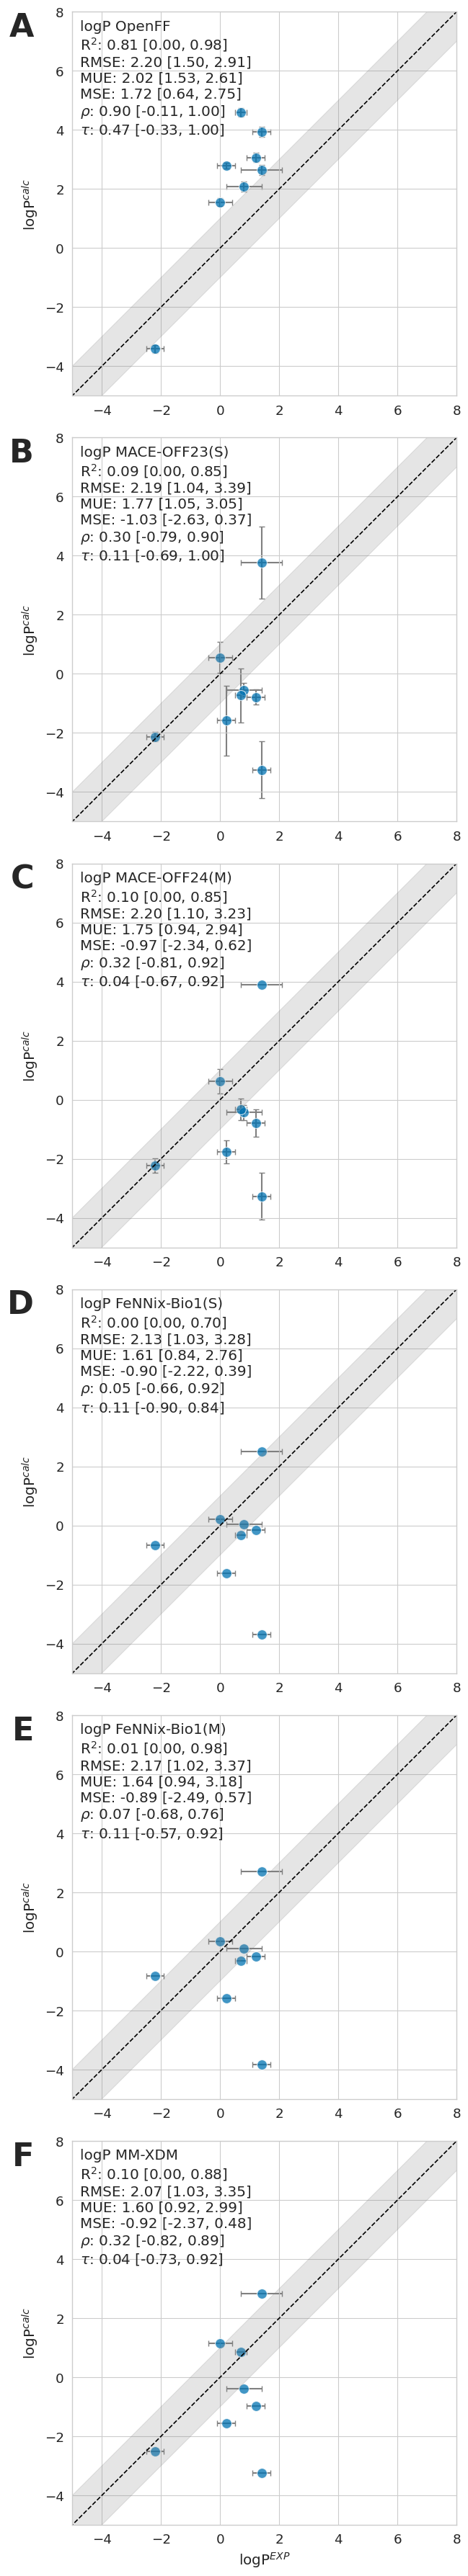

In [71]:
sns.set(style="whitegrid", palette="colorblind", context="paper", font_scale=1.5)

columns_to_plot = [c for c in df_data_mean.columns if c != "logP EXP"]
num_plots = len(columns_to_plot)
ncols = 1
nrows = num_plots

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(7, 6 * nrows), sharex=False, sharey=False
)

axes = np.array(axes).flatten()

xx = np.linspace(-100, 100, 100)
yy = xx

exp_x = df_data_mean["logP EXP"].to_numpy()
exp_xerr = df_data_error["logP EXP"].to_numpy()

for i, column in enumerate(columns_to_plot):
    x = exp_x.copy()
    y = df_data_mean[column].to_numpy()

    # Drop nan at same indices in x and y
    valid_indices = ~(np.isnan(x) | np.isnan(y))
    x_clean = x[valid_indices]
    y_clean = y[valid_indices]

    if len(x_clean) == 0 or len(y_clean) == 0:
        continue

    metrics = ["R2", "RMSE", "MUE", "MSE", "rho", "KTAU"]
    statistics = {}
    statistics_string = ""
    statistic_type = "mle"
    statistic_name = {
        "RMSE": r"RMSE",
        "MUE": r"MUE",
        "MSE": r"MSE",
        "R2": r"R$^2$",
        "rho": r"$\rho$",
        "KTAU": r"$\tau$",
    }
    for statistic in metrics:
        statistics[statistic] = bootstrap_statistic(x_clean, y_clean, statistic=statistic)
        s = statistics[statistic]
        string = (
            f"{statistic_name[statistic]}: {s[statistic_type]:.2f} [{s['low']:.2f}, {s['high']:.2f}]"
            + "\n"
        )
        statistics_string += string

    sns.lineplot(ax=axes[i], x=xx, y=yy, color="black", linestyle="--")
    sns.scatterplot(ax=axes[i], x=x_clean, y=y_clean, alpha=0.75, s=100)

    axes[i].errorbar(
        x_clean,
        y_clean,
        xerr=exp_xerr[valid_indices],
        yerr=df_data_error[column].to_numpy()[valid_indices],
        fmt="none",
        ecolor="gray",
        elinewidth=1.5,
        capsize=3,
        alpha=1.0,
        zorder=0,
    )

    axes[i].set_ylabel(r"logP$^{calc}$")

    if i == num_plots - 1:
        axes[i].set_xlabel(r"logP$^{EXP}$")

    small_dist = 1.0
    scale = np.linspace(-100, 100, 100)
    axes[i].fill_between(
        scale,
        scale - small_dist,
        scale + small_dist,
        color="grey",
        alpha=0.2,
    )

    axes[i].text(
        0.02,
        0.98,
        f"{column}\n{statistics_string}",
        transform=axes[i].transAxes,
        ha="left",
        va="top",
    )

    axes[i].grid(True)
    axes[i].set_xlim(-5, 8)
    axes[i].set_ylim(-5, 8)

labels = ["A", "B", "C", "D", "E", "F", "G", "H"]
for ax, label in zip(axes, labels):
    ax.set_aspect("equal", "box")
    ax.text(
        -0.10,
        1.0,
        label,
        transform=ax.transAxes,
        fontsize=32,
        fontweight="bold",
        va="top",
        ha="right",
    )

plt.tight_layout()
plt.savefig("logP_benchmark.pdf", bbox_inches="tight", dpi=300, transparent=True)
plt.show()


# Statistical Analysis

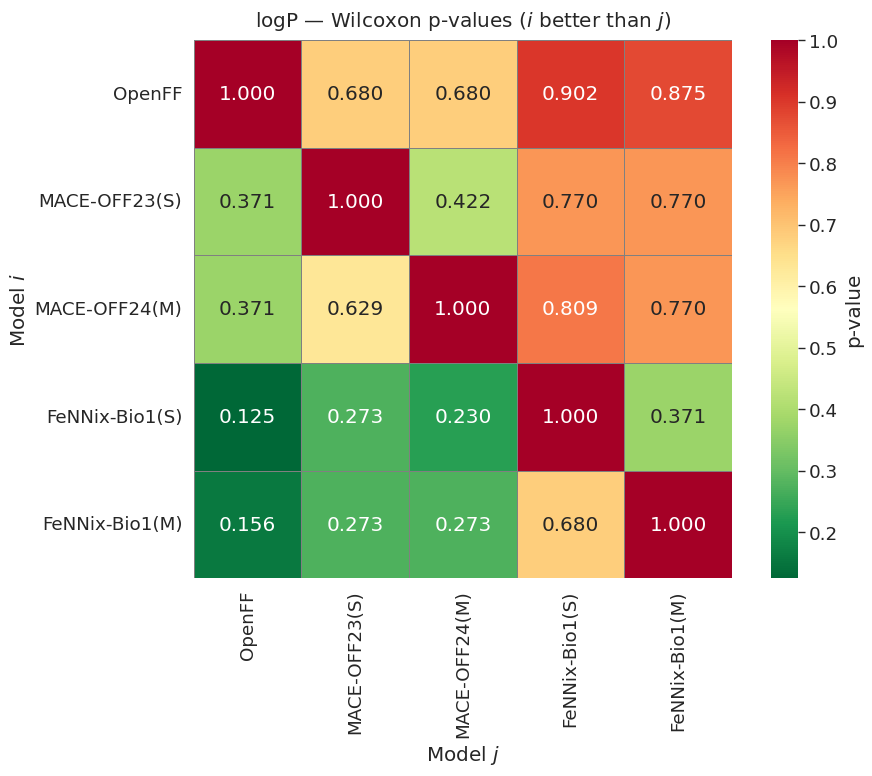

In [72]:
from scipy.stats import wilcoxon

exp_logP = df_data_mean["logP EXP"].to_numpy()

abs_error_MM = np.abs(df_data_mean["logP OpenFF"].to_numpy() - exp_logP)
abs_error_MACE_OFF23_S = np.abs(df_data_mean["logP MACE-OFF23(S)"].to_numpy() - exp_logP)
abs_error_MACE_OFF24_M = np.abs(df_data_mean["logP MACE-OFF24(M)"].to_numpy() - exp_logP)
abs_error_FENNIX_S = np.abs(df_data_mean["logP FeNNix-Bio1(S)"].to_numpy() - exp_logP)
abs_error_FENNIX_M = np.abs(df_data_mean["logP FeNNix-Bio1(M)"].to_numpy() - exp_logP)

names = ["OpenFF", "MACE-OFF23(S)", "MACE-OFF24(M)", "FeNNix-Bio1(S)", "FeNNix-Bio1(M)"]
all_errors = [abs_error_MM, abs_error_MACE_OFF23_S, abs_error_MACE_OFF24_M, abs_error_FENNIX_S, abs_error_FENNIX_M]


def compute_wilcoxon_matrix(errors):
    n = len(errors)
    p_values = np.ones((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                try:
                    _, p = wilcoxon(errors[i], errors[j], alternative="less")
                    p_values[i, j] = p
                except ValueError:
                    p_values[i, j] = np.nan
    return p_values


p_values = compute_wilcoxon_matrix(all_errors)

sns.set(style="whitegrid", palette="colorblind", context="paper", font_scale=1.5)
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

sns.heatmap(
    p_values,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn_r",
    xticklabels=names,
    yticklabels=names,
    cbar_kws={"label": "p-value", "shrink": 1.0},
    linewidths=0.5,
    linecolor="gray",
    square=True,
    ax=ax,
)
ax.set_xlabel("Model $j$")
ax.set_ylabel("Model $i$")
ax.set_title(r"logP — Wilcoxon p-values ($i$ better than $j$)", pad=10)

plt.tight_layout()
plt.savefig("logP_wilcoxon_pvalues.pdf", bbox_inches="tight", dpi=300, transparent=True)
plt.show()


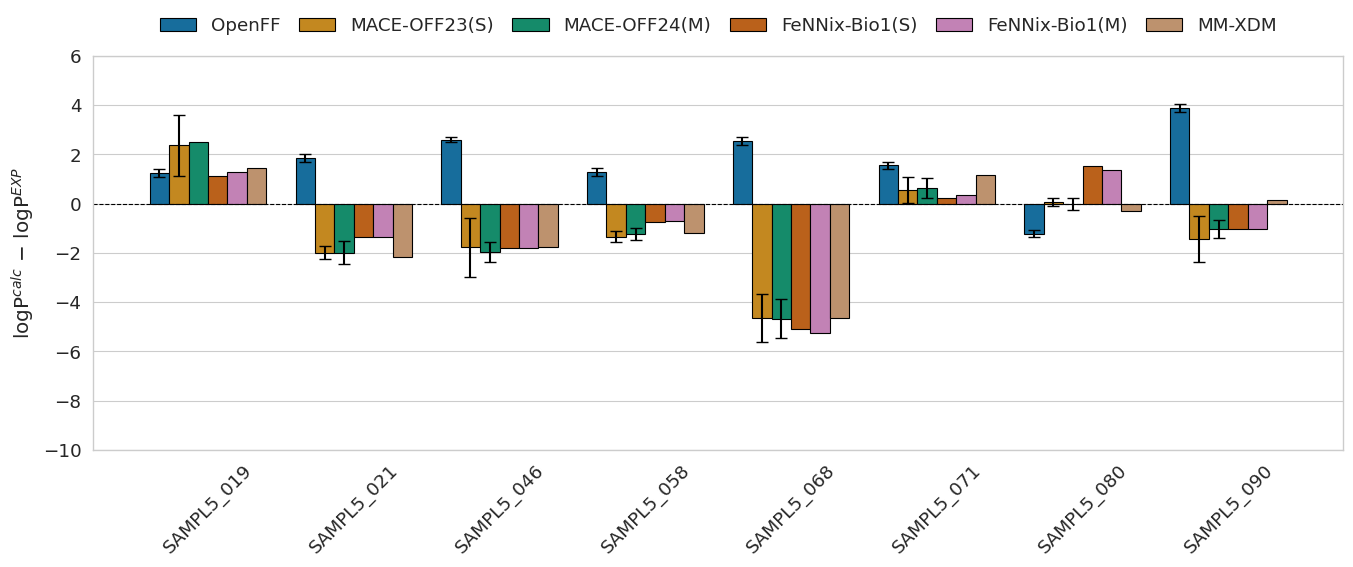

In [73]:
exp = df_data_mean["logP EXP"]
n_mol = len(exp)

model_cols = [c for c in df_data_mean.columns if c != "logP EXP"]
model_display = {
    "logP OpenFF": "OpenFF",
    "logP MACE-OFF23(S)": "MACE-OFF23(S)",
    "logP MACE-OFF24(M)": "MACE-OFF24(M)",
    "logP FeNNix-Bio1(S)": "FeNNix-Bio1(S)",
    "logP FeNNix-Bio1(M)": "FeNNix-Bio1(M)",
    "logP MM-XDM": "MM-XDM",
}

rows = []
for col in model_cols:
    signed_error = df_data_mean[col] - exp
    error = df_data_error[col]
    for mol, se, err in zip(MOLECULES, signed_error, error):
        rows.append({"Molecule": mol, "Model": model_display[col], "Mean": se, "Error": err})

df_bar = pd.DataFrame(rows)

palette = dict(zip(model_display.values(), sns.color_palette("colorblind", len(model_cols))))

sns.set(style="whitegrid", palette="colorblind", context="paper", font_scale=1.5)
fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=df_bar,
    x="Molecule",
    y="Mean",
    hue="Model",
    edgecolor="black",
    palette=palette,
    ax=ax,
)

# Manually add error bars
bar_patches = [p for p in ax.patches if p.get_width() > 0]
for idx, patch in enumerate(bar_patches):
    mol_idx = idx % n_mol
    model_idx = idx // n_mol
    col = model_cols[model_idx]
    err = df_data_error[col].iloc[mol_idx]
    height = patch.get_height()
    x = patch.get_x() + patch.get_width() / 2
    ax.errorbar(x, height, yerr=err, ecolor="black", capsize=4, fmt="none", linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel(r"logP$^{calc}$ $-$ logP$^{EXP}$")
ax.set_xlabel("")
ax.set_ylim(-10, 6)
ax.tick_params(axis="x", rotation=45)
ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.14),
    ncol=len(model_cols),
    columnspacing=1.0,
)

plt.tight_layout()
plt.savefig("logP_errors_barplot.pdf", bbox_inches="tight", dpi=300, transparent=True)
plt.show()


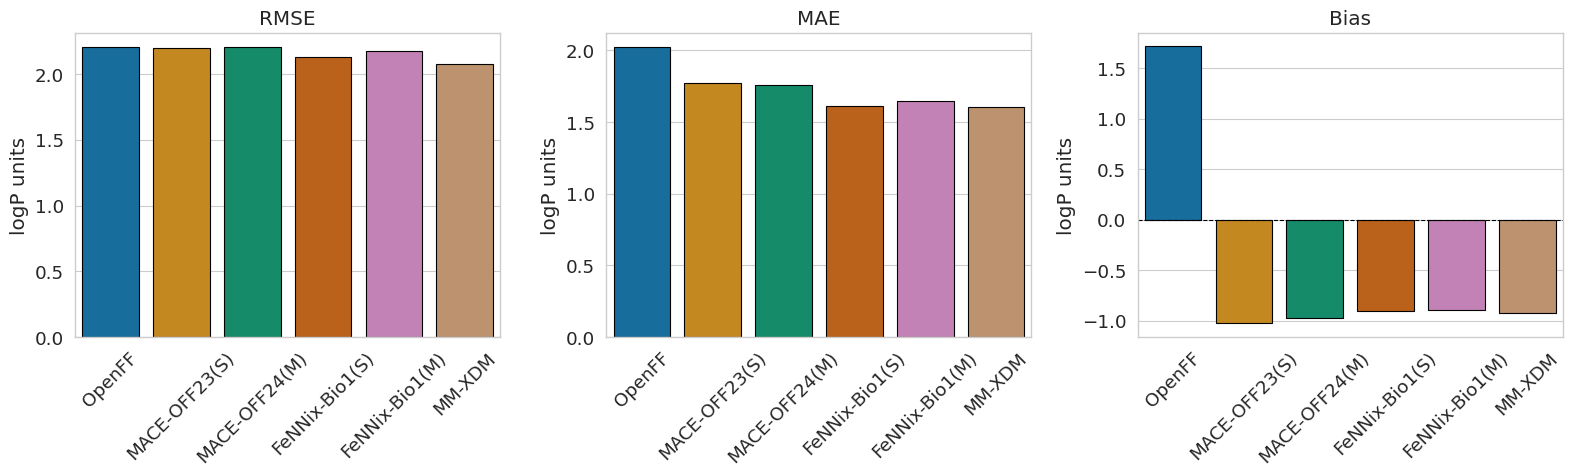

In [74]:
model_cols = [c for c in df_data_mean.columns if c != "logP EXP"]
model_display = {
    "logP OpenFF": "OpenFF",
    "logP MACE-OFF23(S)": "MACE-OFF23(S)",
    "logP MACE-OFF24(M)": "MACE-OFF24(M)",
    "logP FeNNix-Bio1(S)": "FeNNix-Bio1(S)",
    "logP FeNNix-Bio1(M)": "FeNNix-Bio1(M)",
    "logP MM-XDM": "MM-XDM",
}

exp = df_data_mean["logP EXP"].to_numpy()

metric_rows = []
for col in model_cols:
    pred = df_data_mean[col].to_numpy()
    valid = ~(np.isnan(exp) | np.isnan(pred))
    x_v, y_v = exp[valid], pred[valid]

    for metric in ["RMSE", "MUE", "MSE"]:
        s = bootstrap_statistic(x_v, y_v, statistic=metric)
        metric_rows.append({
            "Model": model_display[col],
            "Metric": metric,
            "Value": s["mle"],
            "Low": s["low"],
            "High": s["high"],
        })

df_metrics = pd.DataFrame(metric_rows)

metric_labels = {"RMSE": "RMSE", "MUE": "MAE", "MSE": "Bias"}
df_metrics["Metric"] = df_metrics["Metric"].map(metric_labels)

palette_models = dict(zip(model_display.values(), sns.color_palette("colorblind", len(model_cols))))

sns.set(style="whitegrid", palette="colorblind", context="paper", font_scale=1.5)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, metric_label in zip(axes, ["RMSE", "MAE", "Bias"]):
    df_sub = df_metrics[df_metrics["Metric"] == metric_label].copy()
    bars = sns.barplot(
        data=df_sub,
        x="Model",
        y="Value",
        palette=palette_models,
        edgecolor="black",
        ax=ax,
    )
    """
    for bar, (_, row) in zip(ax.patches, df_sub.iterrows()):
        height = bar.get_height()
        x = bar.get_x() + bar.get_width() / 2
        yerr_low = height - row["Low"]
        yerr_high = row["High"] - height
        ax.errorbar(
            x, height,
            yerr=[[yerr_low], [yerr_high]],
            ecolor="black", capsize=5, fmt="none", linewidth=1.5,
        )
    """
    if metric_label == "Bias":
        ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(metric_label)
    ax.set_xlabel("")
    ax.set_ylabel("logP units")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("logP_metrics_barplot.pdf", bbox_inches="tight", dpi=300, transparent=True)
plt.show()
